In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, Sampler
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd
import numpy as np
import re, gc, os

torch.cuda.empty_cache()
gc.collect()
print(f"GPU: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

GPU: 0.00 GB


In [2]:
# Fix Seed 
import random, os

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seed fixed: {seed}")

SEED = 42
set_seed(SEED)

Seed fixed: 42


## Load Data

In [3]:
train_df = pd.read_csv("/kaggle/input/datasets/nhhongg/tbd-origin/train.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/nhhongg/tbd-origin/test.csv")
val_df   = pd.read_csv("/kaggle/input/datasets/nhhongg/tbd-origin/dev.csv")

print(f"Train: {len(train_df)}, Test: {len(test_df)}, Val: {len(val_df)}")
print("\nTrain distribution:")
print(train_df["label"].value_counts())
print("\nTest distribution:")
print(test_df["label"].value_counts())
print("\nVal distribution:")
print(val_df["label"].value_counts())

Train: 4032, Test: 1427, Val: 629

Train distribution:
label
VAGUE           2012
BEFORE           808
AFTER            674
IS_INCLUDED      273
INCLUDES         206
SIMULTANEOUS      59
Name: count, dtype: int64

Test distribution:
label
VAGUE           638
BEFORE          384
AFTER           274
INCLUDES         56
IS_INCLUDED      53
SIMULTANEOUS     22
Name: count, dtype: int64

Val distribution:
label
VAGUE           254
AFTER           172
BEFORE          156
IS_INCLUDED      21
INCLUDES         14
SIMULTANEOUS     12
Name: count, dtype: int64


In [4]:
# Lọc VAGUE trên tập test
test_df  = test_df [test_df ["label"] != "VAGUE"].reset_index(drop=True)

In [5]:
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("\nTrain label distribution:")
print(train_df["label"].value_counts())
print("\nVal label distribution:")
print(val_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train: 4032, Val: 629, Test: 789

Train label distribution:
label
VAGUE           2012
BEFORE           808
AFTER            674
IS_INCLUDED      273
INCLUDES         206
SIMULTANEOUS      59
Name: count, dtype: int64

Val label distribution:
label
VAGUE           254
AFTER           172
BEFORE          156
IS_INCLUDED      21
INCLUDES         14
SIMULTANEOUS     12
Name: count, dtype: int64

Test label distribution:
label
BEFORE          384
AFTER           274
INCLUDES         56
IS_INCLUDED      53
SIMULTANEOUS     22
Name: count, dtype: int64


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4032 entries, 0 to 4031
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   entity1_id     4032 non-null   object
 1   entity2_id     4032 non-null   object
 2   entity1_start  4032 non-null   int64 
 3   entity2_start  4032 non-null   int64 
 4   entity1_end    4032 non-null   int64 
 5   entity2_end    4032 non-null   int64 
 6   entity1_text   4032 non-null   object
 7   entity2_text   4032 non-null   object
 8   document_id    4032 non-null   object
 9   text           4032 non-null   object
 10  label          4032 non-null   object
dtypes: int64(4), object(7)
memory usage: 346.6+ KB


In [7]:
train_df.head(5)

,entity1_id,entity2_id,entity1_start,entity2_start,entity1_end,entity2_end,entity1_text,entity2_text,document_id,text,label
0,e1,e86,108,122,117,128,predicted,demise,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",BEFORE
1,e1,e2,108,159,117,164,predicted,tried,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",VAGUE
2,e1,e4,108,168,117,174,predicted,hasten,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",VAGUE
3,e86,e2,122,159,128,164,demise,tried,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",AFTER
4,e86,e4,122,168,128,174,demise,hasten,ABC19980120.1830.0957,"ABC19980120.1830.0957 NEWS STORY For his part,...",VAGUE


In [8]:
def insert_tags_fast(text_chunk, s1, e1, s2, e2):
    insertions = [(s1, "<e1>"), (e1, "</e1>"), (s2, "<e2>"), (e2, "</e2>")]
    insertions.sort(key=lambda x: x[0], reverse=True)
    text_list = list(text_chunk)
    for pos, tag in insertions:
        if pos == -1:
            continue
        pos = max(0, min(len(text_list), pos))
        text_list.insert(pos, tag)
    return "".join(text_list)


def find_boundary(text, idx, direction="left"):
    limit = 50
    if direction == "left":
        start = max(0, idx - limit)
        sub = text[start:idx]
        matches = list(re.finditer(r"[\s\.]", sub))
        return start + matches[-1].end() if matches else idx
    else:
        end = min(len(text), idx + limit)
        sub = text[idx:end]
        matches = list(re.finditer(r"[\s\.]", sub))
        return idx + matches[0].start() if matches else idx


def create_chunk(full_text, s1, e1, s2, e2, max_len=256):
    span_start = min(s1, s2)
    span_end   = max(e1, e2)
    dist       = span_end - span_start
    max_char_len = (max_len - 10) * 3

    if dist > max_char_len:
        pad = 50
        c1_s = max(0, s1 - pad); c1_e = min(len(full_text), e1 + pad)
        c2_s = max(0, s2 - pad); c2_e = min(len(full_text), e2 + pad)
        chunk1 = insert_tags_fast(full_text[c1_s:c1_e], s1-c1_s, e1-c1_s, -1, -1)
        chunk2 = insert_tags_fast(full_text[c2_s:c2_e], -1, -1, s2-c2_s, e2-c2_s)
        return chunk1 + " [SEP] " + chunk2

    remaining_chars = max_char_len - dist
    padding     = int(remaining_chars / 2)
    raw_start   = max(0, span_start - padding)
    raw_end     = min(len(full_text), span_end + padding)
    final_start = find_boundary(full_text, raw_start, "left")
    final_end   = find_boundary(full_text, raw_end,   "right")
    chunk_text  = full_text[final_start:final_end]
    return insert_tags_fast(
        chunk_text,
        s1 - final_start, e1 - final_start,
        s2 - final_start, e2 - final_start,
    )


def run_preprocessing(df, max_len=256):
    tqdm.pandas(desc="Processing")
    df["processed_text"] = df.progress_apply(
        lambda row: create_chunk(
            row["text"],
            row["entity1_start"], row["entity1_end"],
            row["entity2_start"], row["entity2_end"],
            max_len=max_len,
        ),
        axis=1,
    )
    return df

print("Preprocessing Train...")
train_df = run_preprocessing(train_df)
print("Preprocessing Val...")
val_df   = run_preprocessing(val_df)
print("Preprocessing Test...")
test_df  = run_preprocessing(test_df)

Preprocessing Train...


Processing: 100%|██████████| 4032/4032 [00:00<00:00, 28267.79it/s]


Preprocessing Val...


Processing: 100%|██████████| 629/629 [00:00<00:00, 31624.58it/s]


Preprocessing Test...


Processing: 100%|██████████| 789/789 [00:00<00:00, 31389.55it/s]


## Dataset

In [9]:
class TBDDataset(Dataset):
    LABEL_MAP = {
        "BEFORE":       0,
        "AFTER":        1,
        "INCLUDES":     2,
        "IS_INCLUDED":  3,
        "SIMULTANEOUS": 4,
        "VAGUE":        5,
    }

    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row     = self.data.iloc[idx]
        encoded = self.tokenizer(
            row["processed_text"],
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        input_ids      = encoded["input_ids"].flatten()
        attention_mask = encoded["attention_mask"].flatten()
        token_type_ids = encoded.get(
            "token_type_ids", torch.zeros_like(input_ids)
        ).flatten()

        e1_id = self.tokenizer.convert_tokens_to_ids("<e1>")
        e2_id = self.tokenizer.convert_tokens_to_ids("<e2>")

        def find_pos(ids, target_id):
            matches = (ids == target_id).nonzero(as_tuple=False)
            if len(matches) > 0:
                return torch.clamp(matches[0][0], 0, self.max_length - 1)
            return torch.tensor(0)

        e1_pos = find_pos(input_ids, e1_id)
        e2_pos = find_pos(input_ids, e2_id)

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "labels":         torch.tensor(self.LABEL_MAP.get(row["label"], -1), dtype=torch.long),
            "e1_pos":         e1_pos,
            "e2_pos":         e2_pos,
            "event1_id":      f"{row['document_id']}_{row['entity1_id']}",
            "event2_id":      f"{row['document_id']}_{row['entity2_id']}",
            "document_id":    row["document_id"],
        }


import numpy as np
from torch.utils.data import Sampler

class SmartBatchSampler(Sampler):
    """
    Gom các cặp trong cùng document vào cùng batch.
    """
    def __init__(self, dataframe, batch_size):
        self.batch_size  = batch_size
        self.doc_groups  = {}
        
        # Gom index theo từng document_id
        for idx, row in dataframe.iterrows():
            self.doc_groups.setdefault(row["document_id"], []).append(idx)
            
        self.doc_ids = list(self.doc_groups.keys())

    def __iter__(self):
        # Xáo trộn thứ tự các Document (Rất cần thiết để mô hình không học vẹt)
        np.random.shuffle(self.doc_ids)
        
        batch = []
        for doc_id in self.doc_ids:
            # Lấy danh sách index của Document hiện tại (GIỮ NGUYÊN THỨ TỰ GỐC)
            idxs = list(self.doc_groups[doc_id])
            
            batch.extend(idxs)
            
            # Cắt thành từng batch đủ kích thước
            while len(batch) >= self.batch_size:
                yield batch[: self.batch_size]
                batch = batch[self.batch_size :]
                
        # Trả về phần dư (nếu có) ở cuối cùng
        if batch:
            yield batch

    def __len__(self):
        total = sum(len(v) for v in self.doc_groups.values())
        return (total + self.batch_size - 1) // self.batch_size


def collate_fn(batch):
    return {
        "input_ids":      torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "token_type_ids": torch.stack([x["token_type_ids"] for x in batch]),
        "labels":         torch.stack([x["labels"]         for x in batch]),
        "e1_pos":         torch.stack([x["e1_pos"]         for x in batch]),
        "e2_pos":         torch.stack([x["e2_pos"]         for x in batch]),
        "event1_id":      [x["event1_id"]   for x in batch],
        "event2_id":      [x["event2_id"]   for x in batch],
        "document_id":    [x["document_id"] for x in batch],
    }


# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
tokenizer.add_special_tokens(
    {"additional_special_tokens": ["<e1>", "</e1>", "<e2>", "</e2>"]}
)


# Dùng trực tiếp train/val/test đã có sẵn
BATCH_SIZE = 32

train_dataset = TBDDataset(train_df, tokenizer)
val_dataset   = TBDDataset(val_df,   tokenizer)
test_dataset  = TBDDataset(test_df,  tokenizer)

train_sampler = SmartBatchSampler(train_df, BATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False, collate_fn=collate_fn)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 126 batches | Val: 20 batches


## Model

In [10]:
class GeoTREModel(nn.Module):
    def __init__(self, model_name="bert-base-uncased", num_classes=6,
                 hidden=256, dropout=0.1, topk=5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size  = self.encoder.config.hidden_size
        self.topk    = topk

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=8,
            dropout=dropout, batch_first=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.geo_head = nn.Sequential(
            nn.Linear(hidden_size, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

        # Semantic classification head
        self.cls_head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

        # Phân biệt vague 
        self.vague_head = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2),  # 0=non-VAGUE, 1=VAGUE
        )

        # Tolerance cho SIMULTANEOUS
        self.simul_threshold = nn.Parameter(torch.tensor(-2.0))
        # Temperature cho geo logits
        self.geo_temp = nn.Parameter(torch.tensor(0.0))

    def _event_repr(self, hidden_states, pos_idx, attention_mask=None):
        B = hidden_states.size(0)
        h = hidden_states[torch.arange(B), pos_idx]
        query = h.unsqueeze(1)
        key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        _, attn_weights = self.cross_attn(
            query=query, key=hidden_states, value=hidden_states,
            key_padding_mask=key_padding_mask,
        )
        weights = attn_weights.squeeze(1)
        topk_weights, topk_idx = weights.topk(self.topk, dim=-1)
        topk_weights = topk_weights / (topk_weights.sum(dim=-1, keepdim=True) + 1e-9)
        topk_vectors = hidden_states[
            torch.arange(B).unsqueeze(1).expand_as(topk_idx), topk_idx
        ]
        h_context = (topk_weights.unsqueeze(-1) * topk_vectors).sum(dim=1)
        h_rich = self.proj(torch.cat([h, h_context], dim=-1))
        out = self.geo_head(h_rich)
        s = out[:, 0]
        #  min duration 0.05 
        e = s + F.softplus(out[:, 1]) + 0.05
        return s, e, h_rich

    def _compute_geo_logits(self, s1, e1, s2, e2):
        """
        Tính logits hình học dựa trên Allen's Interval Algebra.
        
        Cho 2 event trên trục thời gian:
            E1 = [s1, e1]    E2 = [s2, e2]
        
        5 quan hệ:
            BEFORE:       E1 kết thúc trước khi E2 bắt đầu
            AFTER:        E2 kết thúc trước khi E1 bắt đầu
            INCLUDES:     E1 chứa hẳn E2 (s1 < s2 AND e2 < e1)
            IS_INCLUDED:  E2 chứa hẳn E1 (s2 < s1 AND e1 < e2)
            SIMULTANEOUS: E1 ≈ E2 (gần trùng nhau)
        """
        # ── Khoảng cách giữa 2 cặp biên ──
        d_start = s2 - s1    # > 0 nếu E1 bắt đầu trước E2
        d_end   = e1 - e2    # > 0 nếu E1 kết thúc sau E2
    
        # Ngưỡng tolerance cho mỗi đầu (learnable)
        tol = F.softplus(self.simul_threshold)
    
        # BEFORE: cần gap thực sự giữa e1 và s2 
        # logit > 0 khi s2 > e1 (E1 kết thúc trước E2 bắt đầu)
        logit_before = s2 - e1
    
        # AFTER: đối xứng BEFORE 
        # logit > 0 khi s1 > e2 (E2 kết thúc trước E1 bắt đầu)
        logit_after = s1 - e2
    
        # INCLUDES: E1 chứa E2 
        # Cần ĐỒNG THỜI: d_start > tol (E1 bắt đầu sớm hơn)
        #                 d_end > tol   (E1 kết thúc muộn hơn)
        # min đảm bảo: chỉ dương khi CẢ HAI thỏa mãn
        logit_includes = torch.minimum(d_start, d_end) - tol
    
        # IS_INCLUDED: E2 chứa E1 (đối xứng INCLUDES) 
        # Cần ĐỒNG THỜI: -d_start > tol (E2 bắt đầu sớm hơn)
        #                 -d_end > tol   (E2 kết thúc muộn hơn)
        logit_is_included = torch.minimum(-d_start, -d_end) - tol
    
        # SIMULTANEOUS: E1 ≈ E2
        # dist = tổng lệch ở CẢ HAI đầu
        # 2*tol = tổng ngưỡng (mỗi đầu được lệch tối đa tol)
        dist = torch.abs(d_start) + torch.abs(d_end)
        logit_simultaneous = 2 * tol - dist
    
        # Stack và scale bằng temperature
        logits = torch.stack([
            logit_before,
            logit_after,
            logit_includes,
            logit_is_included,
            logit_simultaneous,
        ], dim=1)
    
        temp = F.softplus(self.geo_temp) + 0.1
        return logits / temp

    def forward(self, input_ids, attention_mask, e1_pos, e2_pos, token_type_ids=None):
        H = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).last_hidden_state

        s1, e1, h1 = self._event_repr(H, e1_pos, attention_mask)
        s2, e2, h2 = self._event_repr(H, e2_pos, attention_mask)

        logits_sem   = self.cls_head(torch.cat([h1, h2], dim=1))
        logits_geo   = self._compute_geo_logits(s1, e1, s2, e2)
        logits_vague = self.vague_head(torch.cat([h1, h2], dim=1)) 

        return s1, e1, s2, e2, logits_sem, logits_geo, logits_vague

## Loss

In [11]:
class TBDLoss(nn.Module):
    """
    total = CE(sem)                           (semantic classification)
          + λ_gce   * CE(geo)                (Allen's geometry → coordinate learning)
          + λ_con   * consistency_loss        (same event = same coordinates)
          + λ_align * KL_sym(sem, geo)        (two branches agree)
    """

    def __init__(self,  lambda_con=0.1,
                 lambda_gce=0.5, lambda_align=0.1, lambda_vague=0.1):
        super().__init__()
        self.register_buffer(
            "class_weights",
            torch.tensor([1.0, 1.2, 3.92, 2.96, 5.0, 0.1])
        )
        self.lambda_con   = lambda_con
        self.lambda_gce   = lambda_gce
        self.lambda_align = lambda_align
        self.lambda_vague = lambda_vague
        print(f"[TBDLoss] CE_sem + {lambda_con}*con "
              f"+ {lambda_gce}*CE_geo + {lambda_align}*KL_align")

    def _consistency_loss(self, s1, e1, s2, e2, event1_ids, event2_ids):
        event_s = {}; event_e = {}
        for i in range(len(s1)):
            event_s.setdefault(event1_ids[i], []).append(s1[i])
            event_s.setdefault(event2_ids[i], []).append(s2[i])
            event_e.setdefault(event1_ids[i], []).append(e1[i])
            event_e.setdefault(event2_ids[i], []).append(e2[i])
        c_losses = []
        for eid in event_s:
            if len(event_s[eid]) < 2: continue
            s_t = torch.stack(event_s[eid]); e_t = torch.stack(event_e[eid])
            c_losses.append(((s_t - s_t.mean().detach())**2).mean() +
                            ((e_t - e_t.mean().detach())**2).mean())
        if not c_losses:
            return torch.tensor(0.0, device=s1.device)
        return torch.stack(c_losses).mean()

    def _vague_separation_loss(self, logits_vague, labels):
        """Binary loss: phân biệt VAGUE (1) vs non-VAGUE (0)"""
        binary_labels = (labels == VAGUE_IDX).long()
        return F.cross_entropy(logits_vague, binary_labels)

    def _alignment_loss(self, logits_sem, logits_geo, eps=1e-8):
        """
        Symmetric KL giữa 2 predicted distributions.
        """
        p_sem = F.softmax(logits_sem[:, :5], dim=-1).clamp(min=eps)  # ← chỉ lấy 5 class
        p_geo = F.softmax(logits_geo,        dim=-1).clamp(min=eps)
        
        kl_fwd = (p_sem * (p_sem.log() - p_geo.log())).sum(-1).mean()
        kl_bwd = (p_geo * (p_geo.log() - p_sem.log())).sum(-1).mean()

        return 0.5 * (kl_fwd + kl_bwd)

    def forward(self, s1, e1, s2, e2, labels, logits_sem, logits_geo=None, logits_vague=None,
                event1_ids=None, event2_ids=None):

        w = self.class_weights.to(logits_sem.device)
        
        # Branch semantic
        ce_sem = F.cross_entropy(logits_sem, labels, weight=w)

        # Consistency
        con_loss = self._consistency_loss(s1, e1, s2, e2, event1_ids, event2_ids) \
                   if (self.lambda_con != 0 and event1_ids is not None) \
                   else torch.tensor(0.0, device=s1.device)

        # Branch geometric CE + Alignment
        ce_geo    = torch.tensor(0.0, device=logits_sem.device)
        aln_loss  = torch.tensor(0.0, device=logits_sem.device)

        if logits_geo is not None:
            ce_geo = F.cross_entropy(logits_geo, labels, weight=w[:5], ignore_index=VAGUE_IDX)
            aln_loss = self._alignment_loss(logits_sem, logits_geo)

        vague_loss = self._vague_separation_loss(logits_vague, labels) \
                 if logits_vague is not None \
                 else torch.tensor(0.0, device=logits_sem.device)

        total = (ce_sem
                 + self.lambda_con   * con_loss
                 + self.lambda_gce   * ce_geo
                 + self.lambda_align * aln_loss
                 + self.lambda_vague * vague_loss)

        return total, ce_sem, con_loss, ce_geo, aln_loss, vague_loss

## Training & Evaluation helpers

In [12]:
LABEL_NAMES  = ["BEFORE", "AFTER", "INCLUDES", "IS_INCLUDED", "SIMULTANEOUS", "VAGUE"]
NUM_CLASSES  = 6
VAGUE_IDX    = 5                        # index của VAGUE để mask khi tính F1
EVAL_LABELS  = list(range(5))  

def train_epoch(model, loader, criterion, optimizer, device, scheduler=None):
    model.train()
    total = ce_sum = con_sum = gce_sum = aln_sum = vag_sum = 0.0 

    bar = tqdm(loader, desc="  Train")
    for batch in bar:
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)
        ev1_ids        = batch["event1_id"]
        ev2_ids        = batch["event2_id"]

        optimizer.zero_grad()
        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )

        loss, ce, con, gce, aln, vag = criterion(
            s1, e1, s2, e2, labels,
            logits_sem, logits_geo, logits_vague, 
            ev1_ids, ev2_ids
        )
        if loss.dim() > 0: loss = loss.mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler: scheduler.step()

        total   += loss.item()
        ce_sum  += ce.item()
        con_sum += con.item()
        gce_sum += gce.item()
        aln_sum += aln.item()
        vag_sum += vag.item()  # ← thêm

        bar.set_postfix(loss=f"{loss.item():.3f}", ce=f"{ce.item():.3f}",
                    gce=f"{gce.item():.3f}", vag=f"{vag.item():.3f}")

    n = len(loader)
    return total/n, ce_sum/n, con_sum/n, gce_sum/n, aln_sum/n, vag_sum/n 

@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total = 0.0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc="  Val  "):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        loss, ce, con, gce, aln, vag = criterion(
            s1, e1, s2, e2, labels, logits_sem, logits_geo, logits_vague
        )
        if loss.dim() > 0: loss = loss.mean()
        total += loss.item()

        # Quyết định cuối dùng logits_sem (branch chính)
        preds = logits_sem.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total / len(loader)
    acc = accuracy_score(all_labels, all_preds)
    mask = np.array(all_labels) != VAGUE_IDX
    f1   = f1_score(np.array(all_labels)[mask], np.array(all_preds)[mask],
                    labels=EVAL_LABELS,
                    average="macro", zero_division=0)
    return avg_loss, acc, f1

## Khởi tạo model, optimizer, criterion

In [13]:
if "model"     in dir(): del model
if "optimizer" in dir(): del optimizer
if "criterion" in dir(): del criterion
gc.collect(); torch.cuda.empty_cache()

# Cấu hình
EPOCHS      = 40
LR          = 2e-5
PATIENCE    = 5
SAVE_PATH   = "/kaggle/working/model_final_tbd_no_con_loss_seed_42.pth"
LAMBDA_CON   = 0
LAMBDA_GCE   = 0.5
LAMBDA_ALIGN = 0.1
LAMBDA_VAGUE = 0.1

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GeoTREModel(model_name="bert-base-uncased", num_classes=NUM_CLASSES)
model.encoder.resize_token_embeddings(len(tokenizer))

if torch.cuda.device_count() > 1:
    print(f"--> {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

criterion = TBDLoss(
    lambda_con=LAMBDA_CON,
    lambda_gce=LAMBDA_GCE,
    lambda_align=LAMBDA_ALIGN,
    lambda_vague=LAMBDA_VAGUE,
)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

from transformers import get_linear_schedule_with_warmup
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


--> 2 GPUs
[TBDLoss] CE_sem + 0*con + 0.5*CE_geo + 0.1*KL_align
Total steps: 5040 | Warmup steps: 504


## Training loop

In [14]:
best_f1           = 0.0
loss_patience_cnt = 0
prev_train_loss   = float("inf")

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_ce, tr_con, tr_gce, tr_aln, tr_vag = train_epoch(  
        model, train_loader, criterion, optimizer, device, scheduler
    )

    val_loss, val_acc, val_f1 = eval_epoch(
        model, val_loader, criterion, device
    )

    print(f"  Train: total={tr_loss:.4f}  ce={tr_ce:.4f}  "
          f"con={tr_con:.4f}  "
          f"gce={tr_gce:.4f}  aln={tr_aln:.4f}  vag={tr_vag:.4f}")  
    print(f"  Val  : loss={val_loss:.4f}  acc={val_acc:.4f}  macro-F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        core = model.module if isinstance(model, nn.DataParallel) else model
        torch.save(core.state_dict(), SAVE_PATH)
        print(f"  --> Saved! (best F1={best_f1:.4f})")

    if (prev_train_loss - tr_loss) < 0.005:
        loss_patience_cnt += 1
        print(f"   Patience {loss_patience_cnt}/{PATIENCE}")
        if loss_patience_cnt >= PATIENCE:
            print("Early stopping!")
            break
    else:
        loss_patience_cnt = 0

    prev_train_loss = tr_loss

print(f"\nBest Val Macro-F1: {best_f1:.4f}")


Epoch 1/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  3.23it/s]


  Train: total=2.7132  ce=1.7712  con=0.0000  gce=1.7233  aln=0.1064  vag=0.6975
  Val  : loss=2.6290  acc=0.2114  macro-F1=0.1844
  --> Saved! (best F1=0.1844)

Epoch 2/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  3.11it/s]


  Train: total=2.5345  ce=1.6903  con=0.0000  gce=1.5155  aln=0.1670  vag=0.6977
  Val  : loss=2.5078  acc=0.1987  macro-F1=0.2115
  --> Saved! (best F1=0.2115)

Epoch 3/40


...

  Train: total=0.0499  ce=0.0051  con=0.0000  gce=0.0777  aln=0.0488  vag=0.0107
  Val  : loss=6.0011  acc=0.5294  macro-F1=0.3875
   Patience 3/5

Epoch 33/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  3.05it/s]


  Train: total=0.0496  ce=0.0071  con=0.0000  gce=0.0734  aln=0.0487  vag=0.0088
  Val  : loss=6.0290  acc=0.5326  macro-F1=0.3665
   Patience 4/5

Epoch 34/40


  Val  : 100%|██████████| 20/20 [00:06<00:00,  3.03it/s]

  Train: total=0.0464  ce=0.0040  con=0.0000  gce=0.0740  aln=0.0472  vag=0.0064
  Val  : loss=6.0567  acc=0.5390  macro-F1=0.3808
   Patience 5/5
Early stopping!

Best Val Macro-F1: 0.5150


## GRID SEARCH ALPHA TRÊN VAL SET 

In [15]:
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(SAVE_PATH))
model.to(device)
model.eval()

all_logits_sem_val, all_logits_geo_val, all_labels_val = [], [], []
with torch.no_grad():
    for batch in tqdm(val_loader, desc="Val for alpha search"):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        all_logits_sem_val.append(logits_sem.cpu())
        all_logits_geo_val.append(logits_geo.cpu())
        all_labels_val.extend(labels.cpu().numpy())

prob_sem_val   = F.softmax(torch.cat(all_logits_sem_val), dim=-1)
prob_geo_val   = F.softmax(torch.cat(all_logits_geo_val), dim=-1)
all_labels_val = np.array(all_labels_val)

prob_geo_val_pad = F.pad(prob_geo_val, (0, 1), value=0.0)

best_alpha, best_f1_val = 0.0, 0.0
for alpha in np.arange(0.0, 1.05, 0.05):
    prob_combined = alpha * prob_sem_val + (1 - alpha) * prob_geo_val_pad
    preds    = prob_combined.argmax(dim=-1).numpy()
    mask_val = all_labels_val != VAGUE_IDX
    f1_val   = f1_score(all_labels_val[mask_val], preds[mask_val],
                        labels=EVAL_LABELS, average="macro", zero_division=0)
    if f1_val > best_f1_val:
        best_f1_val = f1_val
        best_alpha  = alpha

print(f"Best alpha (val): {best_alpha:.2f} | Val Macro-F1: {best_f1_val:.4f}")

Val for alpha search: 100%|██████████| 20/20 [00:06<00:00,  3.03it/s]

Best alpha (val): 0.30 | Val Macro-F1: 0.5609


## Evaluate on Test set

Testing: 100%|██████████| 25/25 [00:08<00:00,  3.03it/s]


Dùng alpha từ val set: 0.30

  1. SEMANTIC Branch
  Micro-F1: 0.7970  |  Macro-F1: 0.6118
              precision    recall  f1-score   support

      BEFORE     0.9379    0.8255    0.8781       384
       AFTER     0.8995    0.7190    0.7992       274
    INCLUDES     0.6222    0.5000    0.5545        56
 IS_INCLUDED     0.6531    0.6038    0.6275        53
SIMULTANEOUS     0.3750    0.1364    0.2000        22

   micro avg     0.8756    0.7313    0.7970       789
   macro avg     0.6975    0.5569    0.6118       789
weighted avg     0.8673    0.7313    0.7920       789


  2. GEOMETRIC Branch
  Micro-F1: 0.8124  |  Macro-F1: 0.6112
              precision    recall  f1-score   support

      BEFORE     0.8947    0.8854    0.8901       384
       AFTER     0.9020    0.8066    0.8516       274
    INCLUDES     0.4935    0.6786    0.5714        56
 IS_INCLUDED     0.5333    0.7547    0.6250        53
SIMULTANEOUS     0.1667    0.0909    0.1176        22

    accuracy                    

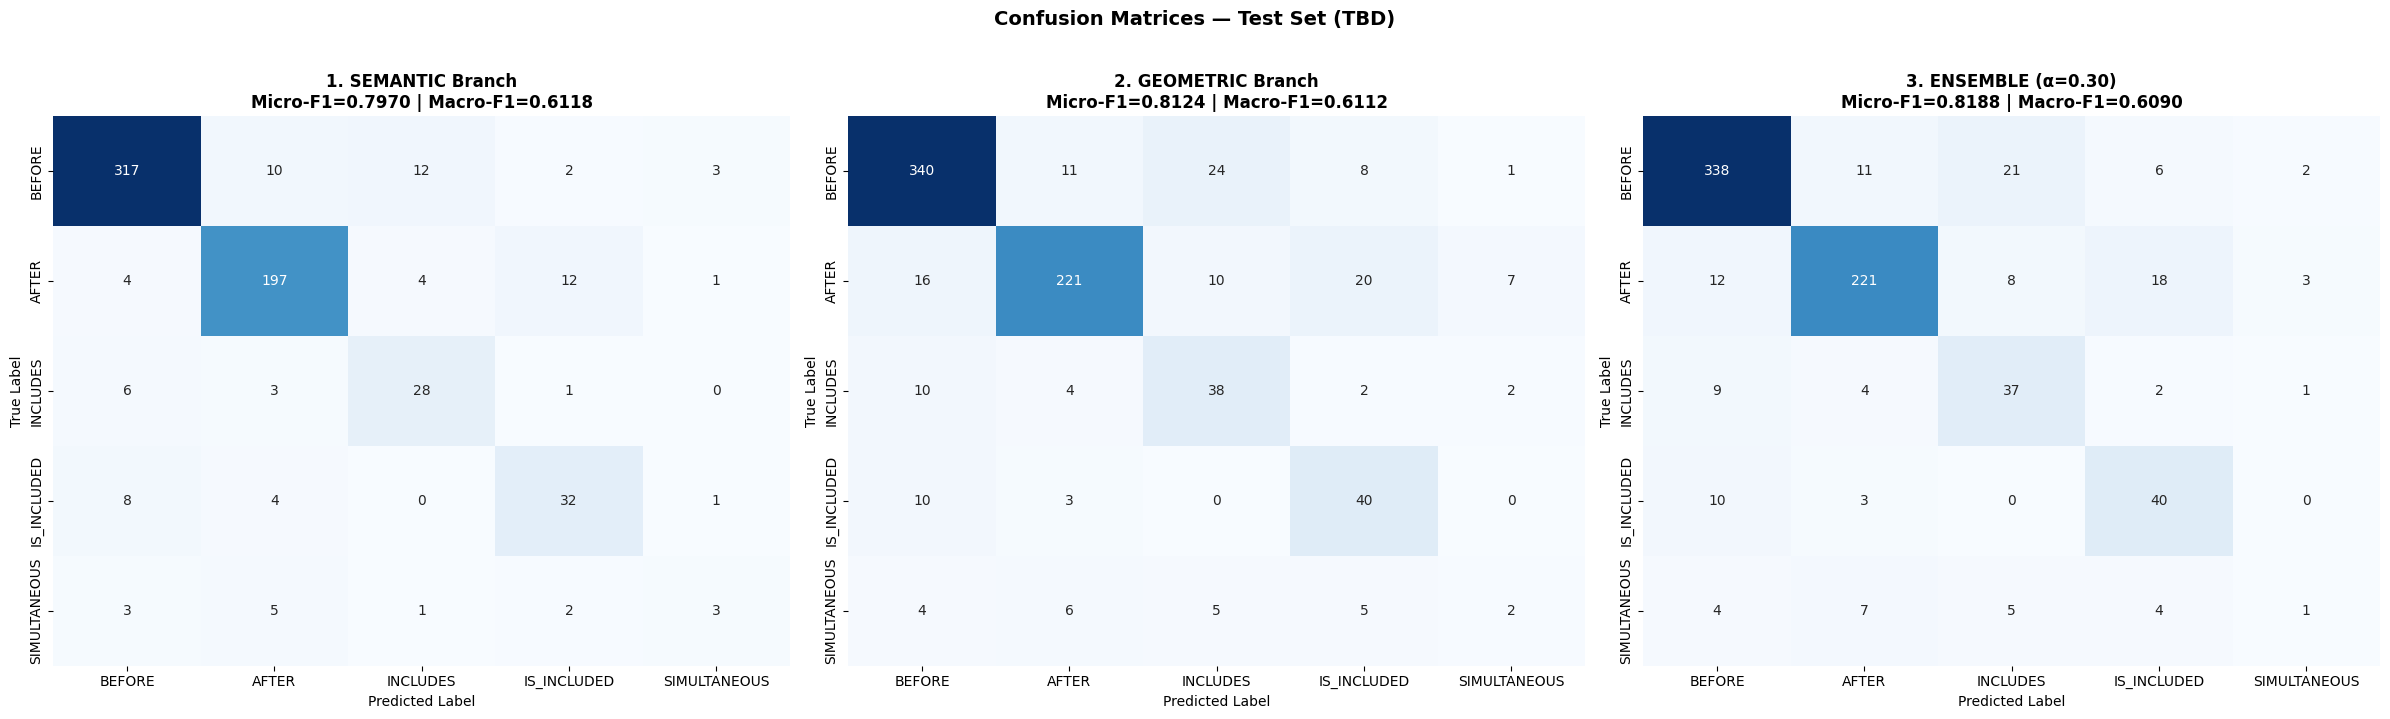


  SUMMARY — TEST SET
  Strategy                            |   Micro-F1 |   Macro-F1
  ------------------------------------+------------+-----------
  1. SEMANTIC Branch                  |     0.7970 |     0.6118
  2. GEOMETRIC Branch                 |     0.8124 |     0.6112
  3. ENSEMBLE (α=0.30)                |     0.8188 |     0.6090


In [16]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

# Load best model 
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(SAVE_PATH))
model.to(device)
model.eval()

# Collect tất cả logits
all_logits_sem = []
all_logits_geo = []
all_labels     = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids      = batch["input_ids"].to(device)
        mask           = batch["attention_mask"].to(device)
        token_type_ids = batch["token_type_ids"].to(device)
        e1_pos         = batch["e1_pos"].to(device)
        e2_pos         = batch["e2_pos"].to(device)
        labels         = batch["labels"].to(device)

        s1, e1, s2, e2, logits_sem, logits_geo, logits_vague = model(
            input_ids, mask, e1_pos, e2_pos, token_type_ids
        )
        all_logits_sem.append(logits_sem.cpu())
        all_logits_geo.append(logits_geo.cpu())
        all_labels.extend(labels.cpu().numpy())

all_logits_sem = torch.cat(all_logits_sem, dim=0)
all_logits_geo = torch.cat(all_logits_geo, dim=0)
all_labels     = np.array(all_labels)

prob_sem = F.softmax(all_logits_sem, dim=-1)
prob_geo = F.softmax(all_logits_geo, dim=-1)

print(f"Dùng alpha từ val set: {best_alpha:.2f}")

# TÍNH PREDICTIONS CHO CẢ 3 NHÁNH
preds_sem  = all_logits_sem.argmax(dim=-1).numpy()
preds_geo  = all_logits_geo.argmax(dim=-1).numpy()
prob_geo_pad = F.pad(prob_geo, (0, 1), value=0.0)
prob_best = best_alpha * prob_sem + (1 - best_alpha) * prob_geo_pad
preds_ens  = prob_best.argmax(dim=-1).numpy()

strategies = [
    ("1. SEMANTIC Branch",                preds_sem),
    ("2. GEOMETRIC Branch",               preds_geo),
    (f"3. ENSEMBLE (α={best_alpha:.2f})", preds_ens),
]

# CLASSIFICATION REPORT 
for title, preds in strategies:
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)

    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"  Micro-F1: {micro_f1:.4f}  |  Macro-F1: {macro_f1:.4f}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels, preds,
        target_names=LABEL_NAMES[:5],
        labels=EVAL_LABELS,
        zero_division=0, digits=4,
    ))

# CONFUSION MATRIX 
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

for ax, (title, preds) in zip(axes, strategies):
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)

    cm = confusion_matrix(all_labels, preds, labels=EVAL_LABELS)

    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABEL_NAMES[:5], yticklabels=LABEL_NAMES[:5],
        ax=ax, cbar=False,
    )
    ax.set_title(f"{title}\nMicro-F1={micro_f1:.4f} | Macro-F1={macro_f1:.4f}",
                 fontsize=12, fontweight='bold')
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")

plt.suptitle("Confusion Matrices — Test Set (TBD)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# BẢNG TỔNG KẾT
print("\n" + "="*60)
print("  SUMMARY — TEST SET")
print("="*60)
print(f"  {'Strategy':<35} | {'Micro-F1':>10} | {'Macro-F1':>10}")
print(f"  {'-'*35}-+-{'-'*10}-+-{'-'*10}")

for title, preds in strategies:
    micro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=EVAL_LABELS,
                        average="macro", zero_division=0)
    print(f"  {title:<35} | {micro_f1:>10.4f} | {macro_f1:>10.4f}")

print("="*60)